In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, zipfile

DATASET_DIR = '/content/drive/MyDrive/carla_dataset'
EXTRACT_DIR = '/content/carla_dataset'
os.makedirs(EXTRACT_DIR, exist_ok=True)

for fname in os.listdir(DATASET_DIR):
    if fname.endswith('.zip'):
        print(f'Extracting {fname}...')
        with zipfile.ZipFile(os.path.join(DATASET_DIR, fname), 'r') as zf:
            zf.extractall(EXTRACT_DIR)

print('Done!')

Extracting test.zip...
Extracting train.zip...
Extracting validation.zip...
Extracting test-fog.zip...
Extracting test-night.zip...
Extracting test-town-01.zip...
Done!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import time, copy, random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using:', DEVICE)

Using: cuda


In [ ]:
import os

print(pd.read_csv('/content/carla_dataset/train/labels.csv').columns.tolist())

for root, dirs, files in os.walk('/content/carla_dataset/train'):
    print(root, '→', files[:3])

['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']
/content/carla_dataset/train → ['gnss.feather', 'sim.log', 'labels.csv']
/content/carla_dataset/train/.hydra → ['hydra.yaml', 'config.yaml', 'overrides.yaml']
/content/carla_dataset/train/segmentation-front → ['061320.png', '021830.png', '022970.png']
/content/carla_dataset/train/rgb-front → ['020270.jpg', '012290.jpg', '054420.jpg']


In [ ]:
import pandas as pd
import os

train_df = pd.read_csv('/content/carla_dataset/train/labels.csv')
val_df   = pd.read_csv('/content/carla_dataset/validation/labels.csv')
test_df  = pd.read_csv('/content/carla_dataset/test/labels.csv')

for df, folder in [(train_df, 'train'), (val_df, 'validation'), (test_df, 'test')]:
    df['filepath'] = df['frame'].apply(
        lambda f: f'/content/carla_dataset/{folder}/rgb-front/{int(f):06d}.jpg'
    )

    df.rename(columns={
        'has_traffic_light': 'traffic_light',
        'has_pedestrian'   : 'pedestrian',
        'has_vehicle'      : 'vehicle',
    }, inplace=True)

print('Train:', len(train_df))
print('Val:  ', len(val_df))
print('Test: ', len(test_df))
train_df.head()

Train: 7200
Val:   3600
Test:  3600


,frame,traffic_light,pedestrian,vehicle,px_traffic_light,px_pedestrian,px_vehicle,filepath
0,0,False,False,True,0,0,85,/content/carla_dataset/train/rgb-front/000000.jpg
1,10,False,True,True,14,301,1138,/content/carla_dataset/train/rgb-front/000010.jpg
2,20,True,True,True,99,196,517,/content/carla_dataset/train/rgb-front/000020.jpg
3,30,True,True,True,99,181,530,/content/carla_dataset/train/rgb-front/000030.jpg
4,40,True,True,True,101,169,538,/content/carla_dataset/train/rgb-front/000040.jpg


In [ ]:
import os
sample_files = os.listdir('/content/carla_dataset/train/rgb-front')[:5]
print('Sample filenames:', sample_files)
print('Sample frame values:', train_df['frame'].head().tolist())

Sample filenames: ['020270.jpg', '012290.jpg', '054420.jpg', '042620.jpg', '016770.jpg']
Sample frame values: [0, 10, 20, 30, 40]


=== 3.4.1 Image Counts ===
  Training   : 7,200
  Validation : 3,600
  Test       : 3,600


/tmp/ipykernel_1130/1904978302.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pos_rate = counts.get(1, 0) / len(train_df) * 100


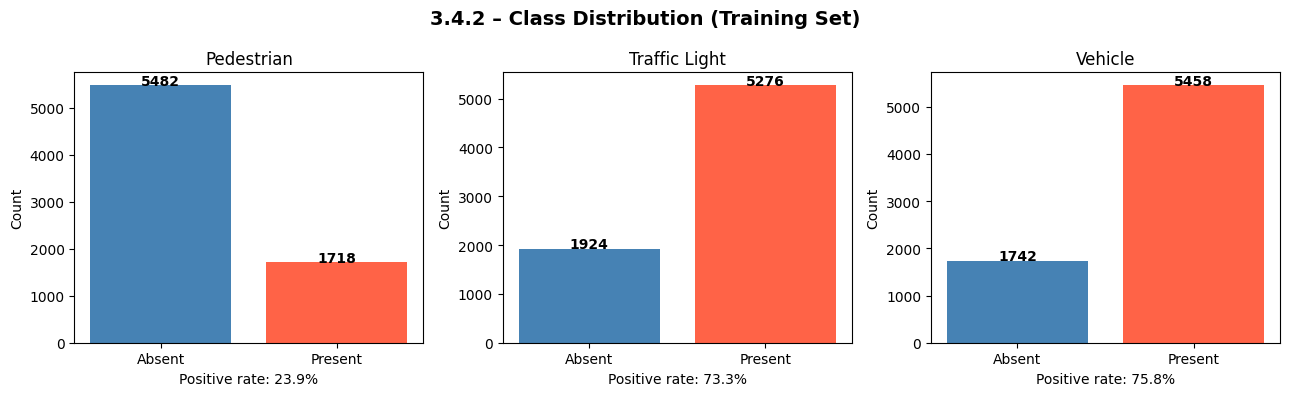


=== 3.4.2 Class Balance ===
  pedestrian     : present=1,718  absent=5,482  positive_rate=23.9%
  traffic_light  : present=5,276  absent=1,924  positive_rate=73.3%
  vehicle        : present=5,458  absent=1,742  positive_rate=75.8%


In [ ]:
LABELS = ['pedestrian', 'traffic_light', 'vehicle']

print('=== 3.4.1 Image Counts ===')
print(f'  Training   : {len(train_df):,}')
print(f'  Validation : {len(val_df):,}')
print(f'  Test       : {len(test_df):,}')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, label in zip(axes, LABELS):
    counts = train_df[label].value_counts().sort_index()
    bars = ax.bar(['Absent', 'Present'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(label.replace('_', ' ').title())
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
    pos_rate = counts.get(1, 0) / len(train_df) * 100
    ax.set_xlabel(f'Positive rate: {pos_rate:.1f}%')

plt.suptitle('3.4.2 – Class Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== 3.4.2 Class Balance ===')
for label in LABELS:
    pos = int(train_df[label].sum())
    neg = len(train_df) - pos
    print(f'  {label:<15}: present={pos:,}  absent={neg:,}  positive_rate={pos/len(train_df):.1%}')

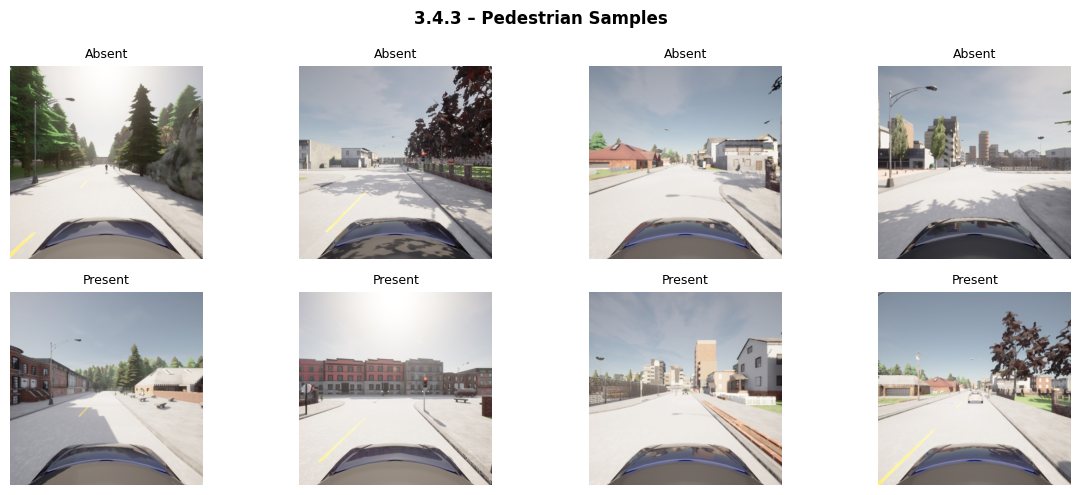

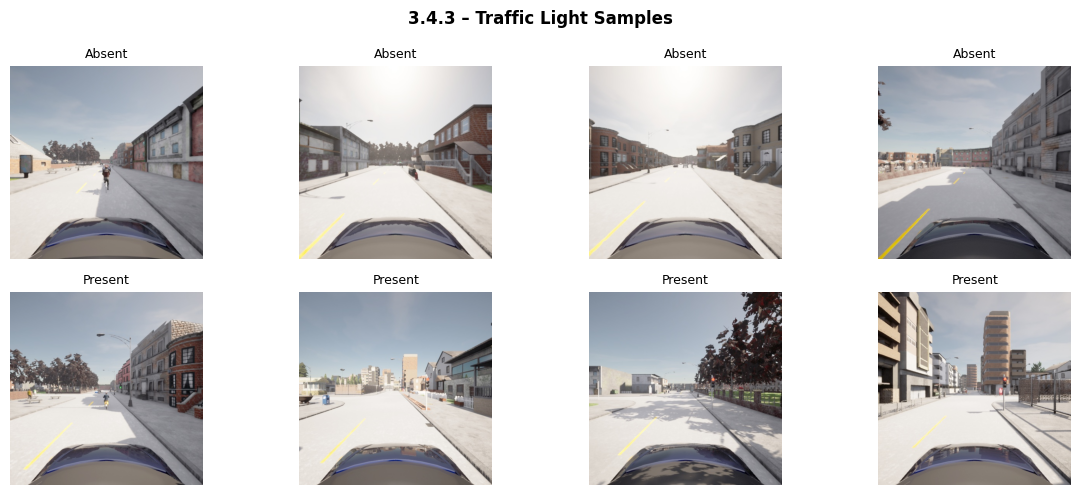

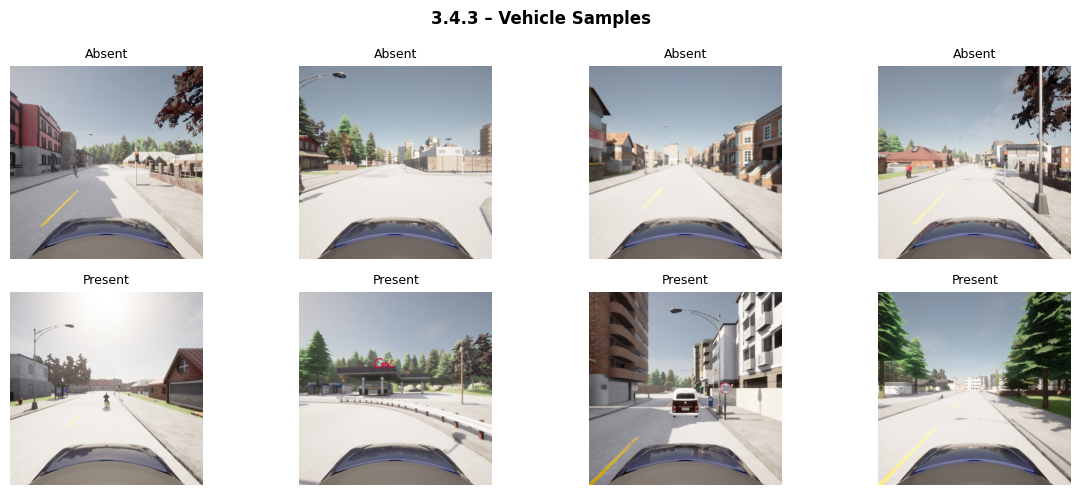

In [ ]:
from PIL import Image

def show_samples(df, label, n=4):
    pos_df = df[df[label] == 1]
    neg_df = df[df[label] == 0]
    n = min(n, len(pos_df), len(neg_df))

    fig, axes = plt.subplots(2, n, figsize=(3*n, 5))
    for row_i, (val, subset) in enumerate([(0, neg_df), (1, pos_df)]):
        for ax, (_, row) in zip(axes[row_i], subset.sample(n=n, random_state=42).iterrows()):
            ax.imshow(Image.open(row['filepath']).convert('RGB'))
            ax.set_title('Present' if val else 'Absent', fontsize=9)
            ax.axis('off')
    plt.suptitle(f'3.4.3 – {label.replace("_"," ").title()} Samples',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

for label in LABELS:
    show_samples(train_df, label)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import copy, time
import numpy as np

class CARLADataset(Dataset):
    def __init__(self, df, label_col, transform):
        self.df        = df.reset_index(drop=True)
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['filepath']).convert('RGB')
        label = torch.tensor(float(row[self.label_col]), dtype=torch.float32)
        return self.transform(img), label


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [ ]:
def train_model(label_col):
    print(f'\n>>> Training: {label_col.upper()}')

    tr_loader  = DataLoader(CARLADataset(train_df, label_col, train_transform),
                            batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader = DataLoader(CARLADataset(val_df,   label_col, test_transform),
                            batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    model    = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 1)
    model    = model.to(DEVICE)

    pos = train_df[label_col].sum()
    neg = len(train_df) - pos
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([neg/pos], dtype=torch.float32).to(DEVICE)
    )
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

    history = {'train_loss': [], 'val_loss': []}
    best_val, best_weights = float('inf'), None

    for epoch in range(10):
        # Train
        model.train()
        tr_loss = 0
        for imgs, labels in tr_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs).squeeze(1), labels)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * len(imgs)
        tr_loss /= len(train_df)

        # Validate
        model.eval()
        vl_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                loss = criterion(model(imgs).squeeze(1), labels)
                vl_loss += loss.item() * len(imgs)
        vl_loss /= len(val_df)

        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'  ].append(vl_loss)

        if vl_loss < best_val:
            best_val     = vl_loss
            best_weights = copy.deepcopy(model.state_dict())

        print(f'  Epoch {epoch+1:>2}/10  train={tr_loss:.4f}  val={vl_loss:.4f}')

    model.load_state_dict(best_weights)
    return model, history


models_dict  = {}
history_dict = {}
for label in LABELS:
    m, h = train_model(label)
    models_dict[label]  = m
    history_dict[label] = h

print('\n✓ All 3 models trained!')


>>> Training: PEDESTRIAN
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


  Epoch  1/10  train=0.8951  val=1.2438
  Epoch  2/10  train=0.6985  val=1.3770
  Epoch  3/10  train=0.5500  val=1.7803
  Epoch  4/10  train=0.4310  val=1.5024
  Epoch  5/10  train=0.3310  val=1.6541
  Epoch  6/10  train=0.2341  val=1.8844
  Epoch  7/10  train=0.1775  val=2.0978
  Epoch  8/10  train=0.1289  val=2.1265
  Epoch  9/10  train=0.1081  val=2.1998
  Epoch 10/10  train=0.0837  val=2.2651

>>> Training: TRAFFIC_LIGHT
  Epoch  1/10  train=0.0978  val=0.0549
  Epoch  2/10  train=0.0437  val=0.0419
  Epoch  3/10  train=0.0291  val=0.0391
  Epoch  4/10  train=0.0220  val=0.0430
  Epoch  5/10  train=0.0165  val=0.0490
  Epoch  6/10  train=0.0141  val=0.0398
  Epoch  7/10  train=0.0108  val=0.0410
  Epoch  8/10  train=0.0059  val=0.0430
  Epoch  9/10  train=0.0045  val=0.0424
  Epoch 10/10  train=0.0038  val=0.0423

>>> Training: VEHICLE
  Epoch  1/10  train=0.1797  val=0.2220
  Epoch  2/10  train=0.1138  val=0.1624
  Epoch  3/10  train=0.0956  val=0.1480
  Epoch  4/10  train=0.0782 

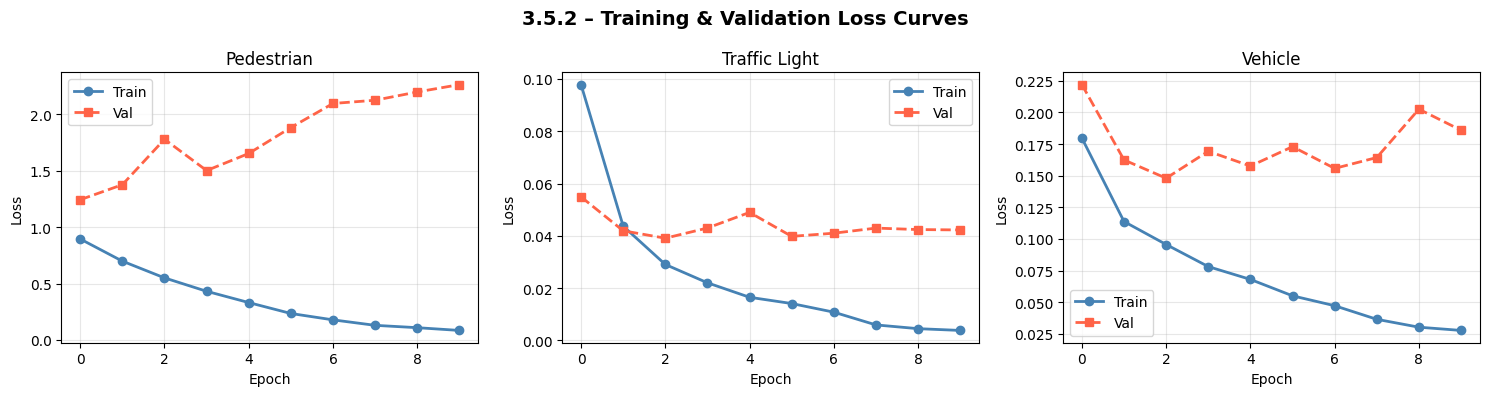

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, label in zip(axes, LABELS):
    h = history_dict[label]
    ax.plot(h['train_loss'], 'o-',  label='Train', color='steelblue', linewidth=2)
    ax.plot(h['val_loss'],   's--', label='Val',   color='tomato',    linewidth=2)
    ax.set_title(label.replace('_', ' ').title(), fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('3.5.2 – Training & Validation Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

@torch.no_grad()
def get_preds(model, df, label_col):
    loader = DataLoader(CARLADataset(df, label_col, test_transform),
                        batch_size=64, shuffle=False, num_workers=2)
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        preds = (torch.sigmoid(model(imgs.to(DEVICE)).squeeze(1)) > 0.5).cpu().int()
        all_preds .extend(preds.tolist())
        all_labels.extend(labels.int().tolist())
    return np.array(all_labels), np.array(all_preds)


print('='*55)
print(f'{"Label":<18} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('='*55)
results = {}
for label in LABELS:
    y_true, y_pred = get_preds(models_dict[label], test_df, label)
    results[label] = (y_true, y_pred)
    acc  = accuracy_score (y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score   (y_true, y_pred, zero_division=0)
    f1   = f1_score       (y_true, y_pred, zero_division=0)
    print(f'{label:<18} {acc:>9.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}')
print('='*55)

print('\n--- Full Reports ---')
for label in LABELS:
    y_true, y_pred = results[label]
    print(f'\n{label.upper()}')
    print(classification_report(y_true, y_pred, target_names=['Absent','Present']))

Label               Accuracy  Precision   Recall       F1
pedestrian            0.6125     0.2619   0.5368   0.3521
traffic_light         0.9417     0.9419   0.9791   0.9602
vehicle               0.8486     0.9900   0.8063   0.8888

--- Full Reports ---

PEDESTRIAN
              precision    recall  f1-score   support

      Absent       0.85      0.63      0.72      2894
     Present       0.26      0.54      0.35       706

    accuracy                           0.61      3600
   macro avg       0.56      0.58      0.54      3600
weighted avg       0.73      0.61      0.65      3600


TRAFFIC_LIGHT
              precision    recall  f1-score   support

      Absent       0.94      0.85      0.89      1016
     Present       0.94      0.98      0.96      2584

    accuracy                           0.94      3600
   macro avg       0.94      0.91      0.93      3600
weighted avg       0.94      0.94      0.94      3600


VEHICLE
              precision    recall  f1-score   support

 

In [16]:
import os

print('=== Folders in carla_dataset ===')
all_folders = os.listdir('/content/carla_dataset')
print(all_folders)

print('\n=== Zip files in Drive (conditions available) ===')
for f in os.listdir('/content/drive/MyDrive/carla_dataset'):
    print(f' - {f}')

=== Folders in carla_dataset ===
['validation', 'train', 'test-fog', 'test-town-01', 'test', 'test-night']

=== Zip files in Drive (conditions available) ===
 - test.zip
 - train.zip
 - validation.zip
 - train
 - test
 - validation
 - test-fog.zip
 - test-night.zip
 - test-town-01.zip


In [17]:

print('=== 3.7.1 – Training Data Conditions ===\n')

train_csv = pd.read_csv('/content/carla_dataset/train/labels.csv')
print(f'Total training frames : {len(train_csv)}')
print(f'Frame range           : {train_csv["frame"].min()} → {train_csv["frame"].max()}')


config_path = '/content/carla_dataset/train/.hydra/config.yaml'
if os.path.exists(config_path):
    print('\n--- Simulation config (train) ---')
    with open(config_path) as f:
        print(f.read())
else:
    print('\nNo config.yaml found.')

simlog_path = '/content/carla_dataset/train/sim.log'
if os.path.exists(simlog_path):
    print('\n--- sim.log (first 30 lines) ---')
    with open(simlog_path) as f:
        for i, line in enumerate(f):
            if i >= 30: break
            print(line, end='')

=== 3.7.1 – Training Data Conditions ===

Total training frames : 7200
Frame range           : 0 → 71990

--- Simulation config (train) ---
data_dir: ./outputs/${simulation.world_name}
name: no-name-set
kill_carla: true
print_config: true
seed: 12345
simulation:
  weather:
    cloudiness: 5.0
    precipitation: 0.0
    sun_altitude_angle: 45.0
    sun_azimuth_angle: -1.0
    fog_density: 2.0
    fog_distance: 0.75
    fog_falloff: 0.1
    precipitation_deposits: 0.0
    wind_intensity: 10.0
    wetness: 0.0
    scattering_intensity: 1.0
    mie_scattering_scale: 0.03
    rayleigh_scattering_scale: 0.0331
    dust_storm: 0.0
  world_name: Town02
  carla:
    bin: /home/ki/projects/work/carla/carla-0.9.14/
    file: CarlaUE4.sh
    quality_level: Epic
    spawn: true
    host: localhost
    port: 2000
    timeout: 120
  ego:
    index: 0
    mode: seed
    seed: ${seed}
    model: vehicle.tesla.model3
    autopilot: true
    percentage_speed: -10.0
    auto_lane_change: true
    ignore_w

In [18]:

print('=== 3.7.2 – ODD Coverage Gap ===\n')

test_conditions = [f for f in os.listdir('/content/carla_dataset') if 'test' in f]
print('Test splits found:', test_conditions)

print("""
ODD Dimension          | Training | Available Test Splits
-----------------------|----------|-------------------------------
Weather: clear/sunny   |   YES    | test/
Weather: fog           |   NO     | test-fog/
Lighting: daytime      |   YES    | test/
Lighting: night        |   NO     | test-night/
Map: default town      |   YES    | test/
Map: town-01           |   NO     | test-town-01/
Dusk / dawn            |   NO     | not available at all
Camera angle variation |   NO     | not available at all
Sensor noise / dirt    |   NO     | not available at all
""")

=== 3.7.2 – ODD Coverage Gap ===

Test splits found: ['test-fog', 'test-town-01', 'test', 'test-night']

ODD Dimension          | Training | Available Test Splits
-----------------------|----------|-------------------------------
Weather: clear/sunny   |   YES    | test/
Weather: fog           |   NO     | test-fog/
Lighting: daytime      |   YES    | test/
Lighting: night        |   NO     | test-night/
Map: default town      |   YES    | test/
Map: town-01           |   NO     | test-town-01/
Dusk / dawn            |   NO     | not available at all
Camera angle variation |   NO     | not available at all
Sensor noise / dirt    |   NO     | not available at all



In [19]:

from sklearn.metrics import recall_score, precision_score, f1_score

def load_split(folder_name):
    """Load a test split if it exists."""
    base = f'/content/carla_dataset/{folder_name}'
    csv_path = f'{base}/labels.csv'
    if not os.path.exists(csv_path):
        return None
    df = pd.read_csv(csv_path)
    files = sorted([f for f in os.listdir(f'{base}/rgb-front') if f.endswith('.jpg')])
    df['filepath'] = [f'{base}/rgb-front/{f}' for f in files[:len(df)]]
    df.rename(columns={
        'has_traffic_light': 'traffic_light',
        'has_pedestrian'   : 'pedestrian',
        'has_vehicle'      : 'vehicle',
    }, inplace=True)
    return df


# Find all test splits
test_splits = {}
for folder in os.listdir('/content/carla_dataset'):
    if folder.startswith('test'):
        df = load_split(folder)
        if df is not None:
            test_splits[folder] = df
            print(f'Loaded split: {folder}  ({len(df)} frames)')


print('\n=== 3.7.3 – Recall per model across ODD conditions ===\n')
print(f'{"Split":<20}', end='')
for label in LABELS:
    print(f'{label:<18}', end='')
print()
print('-' * 75)

split_results = {}
for split_name, split_df in test_splits.items():
    print(f'{split_name:<20}', end='')
    split_results[split_name] = {}
    for label in LABELS:
        y_true, y_pred = get_preds(models_dict[label], split_df, label)
        rec = recall_score(y_true, y_pred, zero_division=0)
        split_results[split_name][label] = rec
        print(f'{rec:<18.4f}', end='')
    print()

Loaded split: test-fog  (3600 frames)
Loaded split: test-town-01  (3600 frames)
Loaded split: test  (3600 frames)
Loaded split: test-night  (3600 frames)

=== 3.7.3 – Recall per model across ODD conditions ===

Split               pedestrian        traffic_light     vehicle           
---------------------------------------------------------------------------
test-fog            0.0737            0.1813            0.4424            
test-town-01        0.5200            0.6173            0.7223            
test                0.5368            0.9791            0.8063            
test-night          0.5014            0.4701            0.8136            


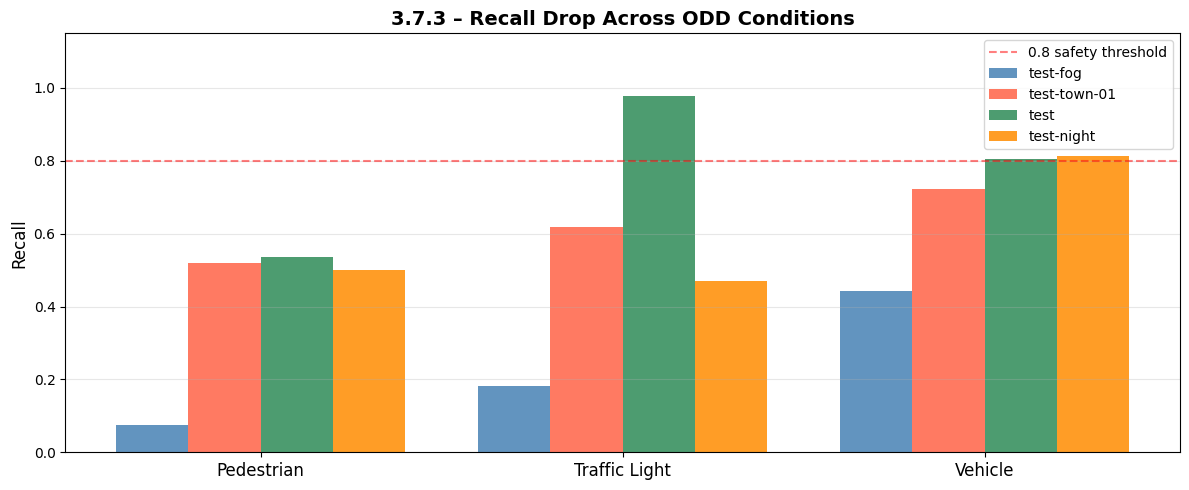

In [21]:

import matplotlib.pyplot as plt
import numpy as np

split_names = list(split_results.keys())
x = np.arange(len(LABELS))
width = 0.8 / len(split_names)
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'purple']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (split_name, color) in enumerate(zip(split_names, colors)):
    vals = [split_results[split_name][label] for label in LABELS]
    offset = (i - len(split_names)/2) * width + width/2
    bars = ax.bar(x + offset, vals, width, label=split_name, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([l.replace('_', ' ').title() for l in LABELS], fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('3.7.3 – Recall Drop Across ODD Conditions', fontsize=14, fontweight='bold')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='0.8 safety threshold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

